# Input Generation — Day-Ahead Spot Prices DE/LU (2025 → 2026-aligned, 15-min)

## Purpose

This notebook generates the **15-minute wholesale electricity price time series** used as the spot price signal in the DT-flex and TCoE-flex optimisation strategies across all archetype–DSO runs.

**Raw input file:** `raw-data/ENTSO-E_DayAhead_DE-LU_2025_retrieved_2026-02.xlsx`  
**Output file (unit: ct/kWh):** `inputs/spot_prices_de_lu_2025_15min.csv`

## Data source

Prices are sourced from the **ENTSO-E Transparency Platform**, Day-Ahead Prices dataset for the DE/LU bidding zone, full calendar year 2025:

> European Network of Transmission System Operators for Electricity [ENTSO-E]. (2025). *Day-ahead prices — DE-LU bidding zone, 2025* [Dataset]. ENTSO-E Transparency Platform. Retrieved February 2026, from https://transparency.entsoe.eu/

## Resolution change — PT60M → PT15M (SDAC go-live)

The 2025 ENTSO-E series is split in temporal resolution:

- **January–September 2025 (PT60M):** Hourly day-ahead prices.
- **October–December 2025 (PT15M):** Quarter-hourly prices, following the SDAC transition to a 15-minute market time unit effective **1 October 2025**.

PT60M rows are converted to PT15M by repeating each hourly value four times (piecewise-constant 1h → 4×15min expansion), producing a uniform 96-slot-per-day format.

## 2026 calendar alignment

The thesis simulation runs on a **2026 calendar** but uses 2025 prices as the spot signal. 2025-01-01 is a Wednesday, but 2026-01-01 is a Thursday — a one-day shift aligns the weekday pattern. The 2025 price series is therefore shifted forward by one day: 2026-01-01 receives 2025-01-02 prices, ..., 2026-12-31 receives 2025-01-01 prices (cyclic wrap).

## Missing values

Gaps within a delivery day are forward-filled row-by-row. Any remaining leading NaN (slot at the very start of a day) is backward-filled from the next valid value. 

## Thesis reference

Chapter 3, Section 3.4 — *Wholesale Spot Prices (15-min)*

In [12]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT  = find_repo_root()
RAW_DATA   = REPO_ROOT / 'data' / 'raw'
INPUTS     = REPO_ROOT / 'inputs'
INPUTS.mkdir(parents=True, exist_ok=True)

RAW_PATH   = RAW_DATA / 'ENTSO-E_DayAhead_DE-LU_2025_retrieved_2026-02.xlsx'
OUTPUT_CSV = INPUTS   / 'spot_prices_de_lu_2025_15min.csv'

# ENTSO-E column names -- robust across export versions; no hardcoded indices
RESOLUTION_COL   = 'Period/resolution'
PRICE_COLS_0TO23 = [f'Period/Point/{i}/price.amount' for i in range(0, 24)]
PRICE_COLS_0TO95 = [f'Period/Point/{i}/price.amount' for i in range(0, 96)]

assert RAW_PATH.exists(), f'Raw file not found: {RAW_PATH}'
print(f'Raw source : {RAW_PATH.name}')
print(f'Output     : {OUTPUT_CSV}')


Raw source : ENTSO-E_DayAhead_DE-LU_2025_retrieved_2026-02.xlsx
Output     : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/spot_prices_de_lu_2025_15min.csv


## Step 1 — Load and inspect the ENTSO-E wide-format table

In [13]:
df = pd.read_excel(RAW_PATH, sheet_name=0)

assert RESOLUTION_COL in df.columns
assert all(c in df.columns for c in PRICE_COLS_0TO95), 'Not all 96 price columns found'

n_pt60m = (df[RESOLUTION_COL] == 'PT60M').sum()
n_pt15m = (df[RESOLUTION_COL] == 'PT15M').sum()
print(f'Rows loaded  : {len(df)}')
print(f'PT60M (1h)   : {n_pt60m} delivery days  (Jan-Sep)')
print(f'PT15M (15min): {n_pt15m} delivery days  (Oct-Dec)')


Rows loaded  : 365
PT60M (1h)   : 273 delivery days  (Jan-Sep)
PT15M (15min): 92 delivery days  (Oct-Dec)


## Step 2 — Convert PT60M rows to PT15M

For PT60M rows the Excel contains 24 hourly values in slots 0–23. Each value is repeated 4 times to produce 96 quarter-hourly values in the same column positions.

In [14]:
pt60m_mask = df[RESOLUTION_COL] == 'PT60M'

for idx in df.index[pt60m_mask]:
    hourly    = df.loc[idx, PRICE_COLS_0TO23].values.astype(float)
    quarterly = np.repeat(hourly, 4)               # 24 -> 96 (NaN-preserving)
    df.loc[idx, PRICE_COLS_0TO95] = quarterly
    df.loc[idx, RESOLUTION_COL]   = 'PT15M'

print(f'Converted {pt60m_mask.sum()} PT60M rows -> PT15M.')
print(f'All rows now PT15M: {(df[RESOLUTION_COL] == "PT15M").all()}')


Converted 273 PT60M rows -> PT15M.
All rows now PT15M: True


## Step 3 — Forward-fill missing values

Within each delivery day, NaN values (from incomplete ENTSO-E exports) are forward-filled. Any leading NaN at the start of a day is backward-filled from the first valid value.

In [15]:
nan_before = int(df[PRICE_COLS_0TO95].isna().sum().sum())

for idx in df.index:
    row = pd.Series(df.loc[idx, PRICE_COLS_0TO95].values, dtype=float)
    df.loc[idx, PRICE_COLS_0TO95] = row.ffill().bfill().values

nan_after = int(df[PRICE_COLS_0TO95].isna().sum().sum())
print(f'NaN before fill : {nan_before}')
print(f'NaN after fill  : {nan_after}')
assert nan_after == 0, 'Unfilled NaN values remain -- inspect manually.'


NaN before fill : 204
NaN after fill  : 0


## Step 4 — Build the flat 15-min series and align to the 2026 calendar

Each row now holds exactly 96 quarter-hourly values. We stack them into a flat 35,040-element array (365 days × 96 slots), then shift by one day so that weekday patterns match the 2026 calendar.

In [16]:
# Flat 2025 series [EUR/MWh]
prices_2025 = df[PRICE_COLS_0TO95].values.astype(float).flatten()  # shape: (35040,)
assert len(prices_2025) == 35_040, f'Expected 35,040, got {len(prices_2025)}'

# 2026 alignment: shift forward one day (cyclic)
# 2025-01-01 = Wednesday; 2026-01-01 = Thursday.
# One-day shift: 2026-01-01 <- 2025-01-02 prices, ..., 2026-12-31 <- 2025-01-01 prices.
prices_2026 = np.concatenate([prices_2025[96:], prices_2025[:96]])

# Convert EUR/MWh -> ct/kWh  (1 EUR/MWh = 0.1 ct/kWh)
# ct/kWh is the unit used throughout the thesis billing pipeline
prices_2026_ct = prices_2026 * 0.1

idx_2026 = pd.date_range('2026-01-01 00:00', periods=35_040, freq='15min')
spot = pd.Series(prices_2026_ct, index=idx_2026, name='price_ct_kWh')

print(f'Series length : {len(spot):,} slots')
print(f'Date range    : {spot.index[0]}  ->  {spot.index[-1]}')
print(f'Min price     : {spot.min():.4f} ct/kWh  ({spot.min()/0.1:.2f} EUR/MWh)')
print(f'Max price     : {spot.max():.4f} ct/kWh  ({spot.max()/0.1:.2f} EUR/MWh)')
print(f'Mean price    : {spot.mean():.4f} ct/kWh  ({spot.mean()/0.1:.2f} EUR/MWh)')


Series length : 35,040 slots
Date range    : 2026-01-01 00:00:00  ->  2026-12-31 23:45:00
Min price     : -25.0320 ct/kWh  (-250.32 EUR/MWh)
Max price     : 58.3400 ct/kWh  (583.40 EUR/MWh)
Mean price    : 8.9555 ct/kWh  (89.55 EUR/MWh)


## Step 5 — Summary statistics

In [17]:
mean_ct   = spot.mean()
std_ct    = spot.std()
cov       = std_ct / mean_ct
min_ct    = spot.min()
max_ct    = spot.max()
neg_share = (spot < 0).mean() * 100

print('DE/LU Day-Ahead Spot Prices 2025 — Summary Statistics')
print('-' * 55)
print(f'  Annual mean           : {mean_ct:.2f} ct/kWh  ({mean_ct/0.1:.2f} EUR/MWh)')
print(f'  Standard deviation    : {std_ct:.2f} ct/kWh')
print(f'  Coeff. of variation   : {cov:.2f}')
print(f'  Minimum (15-min slot) : {min_ct:.2f} ct/kWh  ({min_ct/0.1:.2f} EUR/MWh)')
print(f'  Maximum (15-min slot) : {max_ct:.2f} ct/kWh  ({max_ct/0.1:.2f} EUR/MWh)')
print(f'  Share negative prices : {neg_share:.2f}%')
print('-' * 55)


DE/LU Day-Ahead Spot Prices 2025 — Summary Statistics
-------------------------------------------------------
  Annual mean           : 8.96 ct/kWh  (89.55 EUR/MWh)
  Standard deviation    : 5.23 ct/kWh
  Coeff. of variation   : 0.58
  Minimum (15-min slot) : -25.03 ct/kWh  (-250.32 EUR/MWh)
  Maximum (15-min slot) : 58.34 ct/kWh  (583.40 EUR/MWh)
  Share negative prices : 6.40%
-------------------------------------------------------


## Step 6 — Visualisation

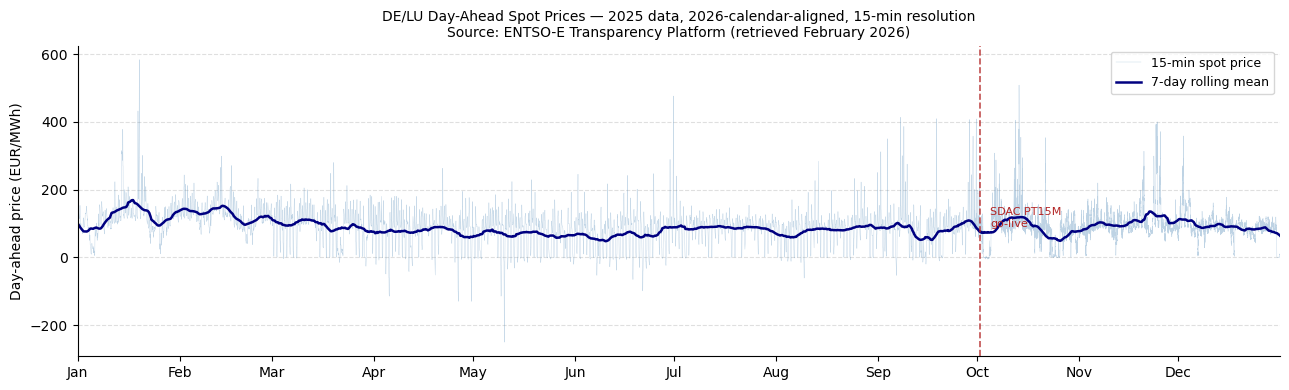

In [18]:
spot_mwh = spot / 0.1   # ct/kWh -> EUR/MWh for display
rolling  = spot_mwh.rolling(window=672, center=True, min_periods=1).mean()   # 7-day rolling mean

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(spot_mwh.index, spot_mwh.values, lw=0.3, alpha=0.35, color="steelblue", label="15-min spot price")
ax.plot(rolling.index, rolling.values, lw=1.8, color="navy", label="7-day rolling mean")

# Mark SDAC PT15M transition (delivery day 2025-10-01, aligned to 2026-10-02 after day shift)
sdac_2026 = pd.Timestamp("2026-10-02")   # one day shifted
ax.axvline(sdac_2026, color="firebrick", lw=1.2, ls="--", alpha=0.8)
ax.text(sdac_2026 + pd.Timedelta(days=3), spot_mwh.quantile(0.92),
        "SDAC PT15M\ngo-live", color="firebrick", fontsize=8, va="top")

ax.set_ylabel('Day-ahead price (EUR/MWh)')
ax.set_title(
    "DE/LU Day-Ahead Spot Prices — 2025 data, 2026-calendar-aligned, 15-min resolution\n"
    "Source: ENTSO-E Transparency Platform (retrieved February 2026)",
    fontsize=10
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlim(spot.index[0], spot.index[-1])
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## Step 7 — Export to CSV

In [20]:
df_out = pd.DataFrame({
    "timestamp"             : spot.index.strftime("%Y-%m-%d %H:%M"),
    "price_ct_kWh": spot.values.round(8),
})

df_out.to_csv(OUTPUT_CSV, index=False)

print(f"Exported : {OUTPUT_CSV}")
print(f"Shape    : {df_out.shape}")
print()
print(df_out.head(6).to_string(index=False))

Exported : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/spot_prices_de_lu_2025_15min.csv
Shape    : (35040, 2)

       timestamp  price_ct_kWh
2026-01-01 00:00         0.255
2026-01-01 00:15         0.255
2026-01-01 00:30         0.255
2026-01-01 00:45         0.255
2026-01-01 01:00         0.156
2026-01-01 01:15         0.156
